# Step 1：指标监控与异常发现

## 业务问题

新用户留存什么时候出现异常？本步骤建立按注册月份计算的D7/D30精确日留存口径，D30为核心结果指标，D7为前置监控指标。此处只负责发现异常，不解释原因。


In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

run_started = time.perf_counter()
project_dir = Path.cwd().resolve()
if project_dir.name == 'notebooks':
    project_dir = project_dir.parent
raw_dir = project_dir / 'data' / 'raw'
processed_dir = project_dir / 'data' / 'processed'
outputs_dir = project_dir / 'outputs'
processed_dir.mkdir(parents=True, exist_ok=True)
outputs_dir.mkdir(parents=True, exist_ok=True)

raw_files = sorted(raw_dir.glob('*.csv'))
raw_before = {p.name: (p.stat().st_size, p.stat().st_mtime_ns) for p in raw_files}
LOG_START = pd.Timestamp('2015-01-01')
LOG_END = pd.Timestamp('2017-03-31')
CHUNK_SIZE = 1_000_000
print(f'Project: {project_dir}')
print(f'Raw CSV files tracked: {len(raw_before)}')

Project: ./
Raw CSV files tracked: 6


## Eligible members

Only `msno` and `registration_init_time` are read. Registration dates before the complete log window are excluded.

In [2]:
members = pd.read_csv(
    raw_dir / 'members_v3.csv',
    usecols=['msno', 'registration_init_time'],
    dtype={'msno': 'object', 'registration_init_time': 'int32'},
)
members['registration_date'] = pd.to_datetime(
    members['registration_init_time'].astype(str), format='%Y%m%d', errors='coerce'
)
members = members.loc[members['registration_date'].between(LOG_START, LOG_END), ['msno', 'registration_date']]
members = members.dropna(subset=['msno', 'registration_date']).drop_duplicates('msno', keep='first').reset_index(drop=True)
members['registration_month'] = members['registration_date'].dt.to_period('M').astype(str)
members['d7_date'] = members['registration_date'] + pd.Timedelta(days=7)
members['d30_date'] = members['registration_date'] + pd.Timedelta(days=30)
members['d7_eligible'] = members['d7_date'].le(LOG_END)
members['d30_eligible'] = members['d30_date'].le(LOG_END)
members['d7_target'] = members['d7_date'].dt.strftime('%Y%m%d').astype('int32')
members['d30_target'] = members['d30_date'].dt.strftime('%Y%m%d').astype('int32')

member_id = pd.Series(np.arange(len(members), dtype=np.int32), index=members['msno'])
d7_target = members['d7_target'].to_numpy(dtype=np.int32)
d30_target = members['d30_target'].to_numpy(dtype=np.int32)
d7_retained = np.zeros(len(members), dtype=bool)
d30_retained = np.zeros(len(members), dtype=bool)
print(f'Registered users within the log window: {len(members):,}')
print(f'Registration range: {members.registration_date.min().date()} to {members.registration_date.max().date()}')

Registered users within the log window: 4,293,876
Registration range: 2015-01-01 to 2017-03-31


## Chunked exact-day log matching

Both log files are streamed with `chunksize`. A user is retained only when a log date equals that user's exact D7 or D30 target date.

In [3]:
rows_scanned = 0
chunks_scanned = 0
for log_name in ['user_logs.csv', 'user_logs_v2.csv']:
    file_rows = 0
    file_started = time.perf_counter()
    reader = pd.read_csv(
        raw_dir / log_name,
        usecols=['msno', 'date'],
        dtype={'msno': 'object', 'date': 'int32'},
        chunksize=CHUNK_SIZE,
    )
    for chunk in reader:
        file_rows += len(chunk)
        rows_scanned += len(chunk)
        chunks_scanned += 1
        mapped = chunk['msno'].map(member_id)
        valid = mapped.notna().to_numpy()
        if valid.any():
            ids = mapped.to_numpy()[valid].astype(np.int32, copy=False)
            dates = chunk['date'].to_numpy(dtype=np.int32, copy=False)[valid]
            hit7 = dates == d7_target[ids]
            hit30 = dates == d30_target[ids]
            if hit7.any():
                d7_retained[ids[hit7]] = True
            if hit30.any():
                d30_retained[ids[hit30]] = True
        if chunks_scanned % 25 == 0:
            print(f'{rows_scanned:,} log rows scanned')
    print(f'{log_name}: {file_rows:,} rows in {(time.perf_counter() - file_started) / 60:.2f} min')
print(f'Total log rows scanned: {rows_scanned:,} in {chunks_scanned} chunks')

25,000,000 log rows scanned


50,000,000 log rows scanned


75,000,000 log rows scanned


100,000,000 log rows scanned


125,000,000 log rows scanned


...

350,000,000 log rows scanned


375,000,000 log rows scanned


user_logs.csv: 392,106,543 rows in 4.74 min


399,106,543 log rows scanned


user_logs_v2.csv: 18,396,362 rows in 0.41 min
Total log rows scanned: 410,502,905 in 412 chunks


## Monthly monitoring table and anomaly candidates

In [4]:
members['d7_retained'] = d7_retained & members['d7_eligible'].to_numpy()
members['d30_retained'] = d30_retained & members['d30_eligible'].to_numpy()
monthly = members.groupby('registration_month', sort=True).agg(
    registered_users=('msno', 'size'),
    d7_eligible_users=('d7_eligible', 'sum'),
    d7_retained_users=('d7_retained', 'sum'),
    d30_eligible_users=('d30_eligible', 'sum'),
    d30_retained_users=('d30_retained', 'sum'),
).reset_index()
for col in ['registered_users', 'd7_eligible_users', 'd7_retained_users', 'd30_eligible_users', 'd30_retained_users']:
    monthly[col] = monthly[col].astype('int64')
monthly['d7_retention_rate'] = monthly['d7_retained_users'].div(monthly['d7_eligible_users'].replace(0, np.nan))
monthly['d30_retention_rate'] = monthly['d30_retained_users'].div(monthly['d30_eligible_users'].replace(0, np.nan))
monthly['prior_3m_d30_avg'] = monthly['d30_retention_rate'].shift(1).rolling(window=3, min_periods=3).mean()
monthly['d30_change_pp'] = monthly['d30_retention_rate'] - monthly['prior_3m_d30_avg']
monthly['d30_relative_change'] = monthly['d30_change_pp'].div(monthly['prior_3m_d30_avg'])

column_order = [
    'registration_month', 'registered_users',
    'd7_eligible_users', 'd7_retained_users', 'd7_retention_rate',
    'd30_eligible_users', 'd30_retained_users', 'd30_retention_rate',
    'prior_3m_d30_avg', 'd30_change_pp', 'd30_relative_change',
]
monthly = monthly[column_order]
csv_path = processed_dir / 'cohort_retention_monitor.csv'
monthly.to_csv(csv_path, index=False, float_format='%.6f')

top10_declines = (monthly.loc[monthly['prior_3m_d30_avg'].notna() & monthly['d30_retention_rate'].notna()]
                  .nsmallest(10, 'd30_change_pp')
                  [['registration_month', 'd30_retention_rate', 'prior_3m_d30_avg',
                    'd30_change_pp', 'd30_relative_change', 'd30_eligible_users']])
print(monthly.to_string(index=False))
print('\nTop 10 D30 declines versus prior 3-month average:')
print(top10_declines.to_string(index=False))

registration_month  registered_users  d7_eligible_users  d7_retained_users  d7_retention_rate  d30_eligible_users  d30_retained_users  d30_retention_rate  prior_3m_d30_avg  d30_change_pp  d30_relative_change
           2015-01            102290             102290              23876           0.233415              102290               10248            0.100186               NaN            NaN                  NaN
           2015-02             92790              92790              20289           0.218655               92790                9331            0.100560               NaN            NaN                  NaN
           2015-03             95388              95388              22702           0.237996               95388               10662            0.111775               NaN            NaN                  NaN
           2015-04             80934              80934              18765           0.231856               80934                9009            0.111313          0.104

## Retention trend

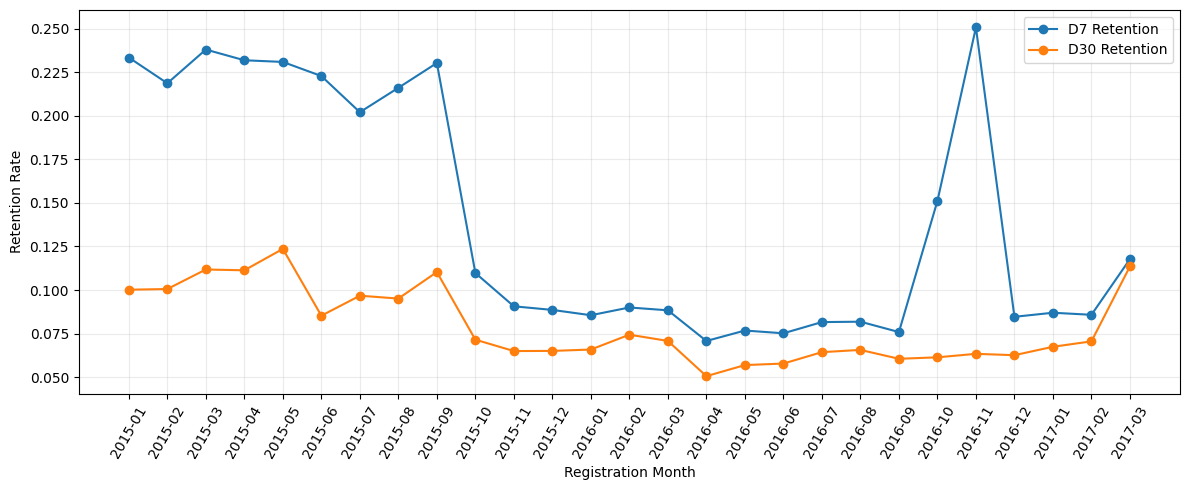

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['registration_month'], monthly['d7_retention_rate'], marker='o', linewidth=1.5, label='D7 Retention')
ax.plot(monthly['registration_month'], monthly['d30_retention_rate'], marker='o', linewidth=1.5, label='D30 Retention')
ax.set_xlabel('Registration Month')
ax.set_ylabel('Retention Rate')
ax.tick_params(axis='x', rotation=60)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plot_path = outputs_dir / 'retention_monitoring.png'
fig.savefig(plot_path, dpi=150)
plt.show()

In [6]:
raw_after = {p.name: (p.stat().st_size, p.stat().st_mtime_ns) for p in raw_files}
raw_unchanged = raw_before == raw_after
total_runtime_seconds = time.perf_counter() - run_started
print(f'CSV output: {csv_path}')
print(f'Plot output: {plot_path}')
print(f'Total runtime: {total_runtime_seconds:.2f} seconds ({total_runtime_seconds / 60:.2f} minutes)')
print(f'Raw files unchanged by size and modification time: {raw_unchanged}')
assert raw_unchanged, 'A raw CSV size or modification timestamp changed during execution.'

CSV output: ./data/processed/cohort_retention_monitor.csv
Plot output: ./outputs/retention_monitoring.png
Total runtime: 369.69 seconds (6.16 minutes)
Raw files unchanged by size and modification time: True


## 教程式结论与下一步

7月至9月基准期D30为10.02%，10月全月D30降至7.15%，同时10月新增用户规模明显增加。

**结论：**2015年10月新用户留存明显下降，同时新增用户规模增加，因此触发异动分析。

**下一步：**先验证异常是否来自日志缺失、观察窗口不足、重复记录或计算口径问题。
